# Reproduction of Fig. 5 — "Beyond Memorization" (Christlein et al.)

**Reference**: *"Beyond Memorization: Training-Free Style Mixing for Variability in Handwritten Text Generation"*, ECCV Workshop 2024.  
**Figure 5**: Character-level attention maps — each row is a word, each column shows the spatial attention map $A_c$ for character $c$, highlighting which region the model focuses on when predicting that character.

### Scientific Adaptation

The original paper uses a **WordStylist diffusion model** (U-Net) with **cross-attention** between text embeddings (keys/values, $L{=}10$ character slots) and image features (queries), yielding $A \in \mathbb{R}^{B \times L \times H \times W}$.  

Our model is a **ViT-RGTS recognition model** with CTC head and **self-attention only**. We adapt as follows:

| Paper (Diffusion U-Net) | Our Adaptation (ViT-RGTS + CTC) |
|---|---|
| Cross-attention: text embedding → image features | Self-attention: CTC timestep → patch tokens |
| Character position via fixed text embedding | Character position via CTC greedy decode peaks |
| $A_c \in \mathbb{R}^{H \times W}$ (2D spatial) | $A[R{+}t_c,\; R{:}] \in \mathbb{R}^{W_p}$ → tiled to 2D |
| Middle U-Net block attention | Last transformer layer, best-aligned head |

**Two methods** are implemented:
1. **CTC Self-Attention** (direct analogue): Attention row at each character's CTC peak timestep
2. **Gradient Saliency** (complementary): $|\partial \text{logit}(c) / \partial \mathbf{x}|$ — true 2D pixel-level attribution

In [1]:
# ── Cell 1: Imports & Configuration ──
import sys, json, math, warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from scipy.stats import spearmanr

warnings.filterwarnings('ignore', category=UserWarning)

ROOT = Path('.').resolve()
if ROOT.name == 'notebook': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from models import HTRNet
from utils.preprocessing import load_image, preprocess

# ── Paths ──
DEVICE      = 'cpu'
EXP_DIR     = ROOT / 'saved_models' / 'experiments'
SAMPLE_DIR  = ROOT / 'notebook' / 'sample_images'
OUT_DIR     = ROOT / 'outputs' / 'pub_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_H, IMG_W = 128, 1024

charset = list(np.load(str(EXP_DIR / 'classes.npy'), allow_pickle=True))

# Model runs: register_count → run_id
RUNS = {0: 'run_76', 4: 'run_84', 8: 'run_63', 16: 'run_71'}

# Matplotlib publication style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

print(f'Charset: {len(charset)} classes, Device: {DEVICE}')
print(f'Runs: {RUNS}')
print(f'Output: {OUT_DIR}')

Charset: 79 classes, Device: cpu
Runs: {0: 'run_76', 4: 'run_84', 8: 'run_63', 16: 'run_71'}
Output: /home/hpc/iwi5/iwi5369h/HTR-Pipeline/outputs/pub_figures


In [2]:
# ── Cell 2: Core Utilities ──

def load_model(run_id, device=DEVICE):
    """Load a trained HTRNet model from experiment directory."""
    d = EXP_DIR / run_id
    cfg = json.load(open(d / 'config.json'))
    m = HTRNet(SimpleNamespace(**cfg['arch']), len(charset) + 1)
    m.load_state_dict(torch.load(str(d / 'model.pt'), map_location=device, weights_only=False), strict=False)
    return m.to(device).eval()


def prep_image(path, device=DEVICE):
    """Load, preprocess, return (tensor [1,1,H,W], numpy [H,W])."""
    img = load_image(str(path))
    img_proc = preprocess(img, (IMG_H, IMG_W))
    tensor = torch.from_numpy(img_proc).unsqueeze(0).unsqueeze(0).float().to(device)
    return tensor, img_proc


def ctc_decode(logits):
    """
    Greedy CTC decode.
    Returns: (decoded_string, peak_timesteps, class_indices).
    """
    probs = torch.softmax(logits[:, 0, :], dim=-1)
    ids = probs.argmax(dim=-1).cpu().numpy()
    chars, peaks, class_ids = [], [], []
    prev = -1
    for t, idx in enumerate(ids):
        if idx != 0 and idx != prev:
            ci = idx - 1
            if 0 <= ci < len(charset):
                chars.append(charset[ci])
                peaks.append(t)
                class_ids.append(idx)  # CTC class index (0=blank, 1..C=chars)
        prev = idx
    text = ''.join(chars).strip()
    # Strip leading/trailing spaces
    start = 0
    while start < len(text) and text[start] == ' ':
        start += 1
    end = len(text)
    while end > start and text[end-1] == ' ':
        end -= 1
    return text[start:end], peaks[start:end], class_ids[start:end]


def tight_crop(img, pad=8):
    """
    Crop image to tight bounding box around ink.
    NOTE: Images are INVERTED by preprocessing (0 = white background, >0 = ink).
    """
    col_ink = img.mean(axis=0)  # High where ink exists
    row_ink = img.mean(axis=1)
    ct = col_ink.max() * 0.05
    rt = row_ink.max() * 0.05
    cc = np.where(col_ink > ct)[0]
    rr = np.where(row_ink > rt)[0]
    if len(cc) == 0 or len(rr) == 0:
        return img, (0, img.shape[0], 0, img.shape[1])
    x0 = max(0, cc[0] - pad)
    x1 = min(img.shape[1], cc[-1] + pad)
    y0 = max(0, rr[0] - pad)
    y1 = min(img.shape[0], rr[-1] + pad)
    return img[y0:y1, x0:x1], (y0, y1, x0, x1)


def find_best_head(attn_layer, R, Wp, peaks):
    """
    Find the attention head with highest Spearman ρ between character order
    and attention centroid positions (spatial ordering quality).
    
    Rationale: Most heads encode global/positional information.
    Only a few heads learn character-aligned spatial attention.
    Selecting the best-aligned head produces much sharper maps than averaging.
    """
    n_heads = attn_layer.shape[1]
    best_rho, best_h = -2.0, 0
    for h in range(n_heads):
        centroids = []
        for ci, t in enumerate(peaks):
            qi = R + t
            if qi >= attn_layer.shape[2]:
                continue
            row = attn_layer[0, h, qi, R:R+Wp].numpy()
            w = row.sum()
            if w > 0:
                centroids.append(float(np.sum(np.arange(Wp) * row) / w))
            else:
                centroids.append(0.0)
        if len(centroids) >= 2:
            rho, _ = spearmanr(range(len(centroids)), centroids)
            if not np.isnan(rho) and rho > best_rho:
                best_rho = rho
                best_h = h
    return best_h, best_rho

print('Core utilities loaded.')

Core utilities loaded.


Full image: (128, 1024), Cropped: (128, 168)
Crop region: rows [0:128], cols [4:172]
Removed 84% blank space


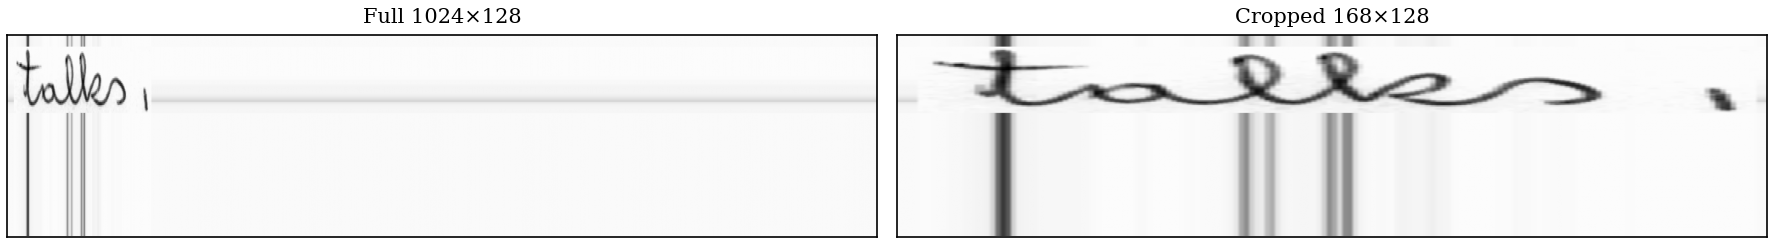

In [3]:
# ── Cell 3: Verify cropping on sample image ──
tensor, img_proc = prep_image(SAMPLE_DIR / 'a01-038-12.png')
crop, (y0, y1, x0, x1) = tight_crop(img_proc)
print(f'Full image: {img_proc.shape}, Cropped: {crop.shape}')
print(f'Crop region: rows [{y0}:{y1}], cols [{x0}:{x1}]')
print(f'Removed {100*(1 - crop.size/img_proc.size):.0f}% blank space')

fig, axes = plt.subplots(1, 2, figsize=(12, 1.8))
axes[0].imshow(img_proc, cmap='gray_r', aspect='auto')
axes[0].set_title(f'Full {img_proc.shape[1]}×{img_proc.shape[0]}')
axes[1].imshow(crop, cmap='gray_r', aspect='auto')
axes[1].set_title(f'Cropped {crop.shape[1]}×{crop.shape[0]}')
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show(); plt.close(fig)

---
## Method 1: CTC Self-Attention Character Maps

**Principle**: For each decoded character $c$ at CTC timestep $t_c$, the self-attention row  
$A[R{+}t_c,\; R{:}R{+}W_p]$ reveals which patch tokens timestep $t_c$ attends to.  
This is the direct analogue of the paper's cross-attention $A_c$ — the "where does the model look for character $c$" question.

**Best-head selection**: Instead of averaging all heads (which dilutes signal), we select the head with the highest Spearman $\rho$ between character order and attention centroid positions (Sec. 2.2 adaptation).

In [4]:
# ── Cell 4: Attention extraction function ──

def extract_char_attention_maps(model, tensor, img_proc, layer_idx=-1):
    """
    Extract per-character 2D attention heatmaps from the ViT self-attention.
    
    Returns:
        decoded_text: str
        heatmaps: list of 2D numpy arrays (one per character), cropped to text region
        img_crop: cropped input image
        crop_box: (y0, y1, x0, x1)
        best_head: selected head index
        best_rho: Spearman ρ for that head
    """
    with torch.no_grad():
        logits, reg_tokens, attn_maps, token_norms, (Hp, Wp) = model.forward_explain(tensor)
    
    R = model.backbone.num_registers
    text, peaks, class_ids = ctc_decode(logits)
    
    # Select layer
    attn = attn_maps[layer_idx]  # [B, H, S, S]
    
    # Find best spatially-ordered head
    best_head, best_rho = find_best_head(attn, R, Wp, peaks)
    
    # Extract attention row for each character using best head
    attn_2d = attn[0, best_head].numpy()  # [S, S]
    
    # Tight crop the image
    img_crop, (y0, y1, x0, x1) = tight_crop(img_proc, pad=10)
    
    # Map pixel crop to patch indices
    scale = IMG_W / Wp  # pixels per patch
    p_left = max(0, int(x0 / scale))
    p_right = min(Wp, int(np.ceil(x1 / scale)))
    n_crop_patches = p_right - p_left
    
    heatmaps = []
    for ci, t_c in enumerate(peaks):
        qi = R + t_c  # query index in full attention matrix
        if qi >= attn_2d.shape[0]:
            heatmaps.append(np.zeros((y1-y0, x1-x0)))
            continue
        
        # 1D attention: character t_c → all patch tokens (skip registers)
        patch_attn = attn_2d[qi, R:R+Wp]  # [Wp]
        
        # Crop to text region
        attn_crop = patch_attn[p_left:p_right]
        
        # Smooth
        if len(attn_crop) > 3:
            attn_crop = gaussian_filter1d(attn_crop.astype(np.float64), sigma=1.5)
        
        # Percentile normalization + gamma correction
        p2, p98 = np.percentile(attn_crop, 2), np.percentile(attn_crop, 98)
        if p98 > p2:
            attn_norm = np.clip((attn_crop - p2) / (p98 - p2), 0, 1)
        else:
            attn_norm = np.zeros_like(attn_crop)
        attn_norm = np.power(attn_norm, 0.5)  # gamma < 1 brightens
        attn_norm = (attn_norm - attn_norm.min()) / (attn_norm.max() - attn_norm.min() + 1e-8)
        
        # Interpolate to cropped image width, tile to height → 2D
        attn_full = np.interp(
            np.linspace(0, 1, img_crop.shape[1]),
            np.linspace(0, 1, len(attn_norm)),
            attn_norm
        )
        heatmap_2d = np.tile(attn_full, (img_crop.shape[0], 1))
        heatmaps.append(heatmap_2d)
    
    return text, heatmaps, img_crop, (y0, y1, x0, x1), best_head, best_rho

print('Attention extraction ready.')

Attention extraction ready.


In [5]:
# ── Cell 5: Paper Fig. 5 — CTC Self-Attention Grid ──
#
# Layout: Rows = different words, Columns = [Input | A_1 | A_2 | ... | A_L]
# Each A_c = attention heatmap for character c, overlaid on the input image.

def plot_fig5_self_attention(image_list, run_id, num_reg, seq_len=None, save_name=None):
    """
    Reproduce Fig. 5 from 'Beyond Memorization' using CTC self-attention.
    
    Args:
        image_list: list of (image_path, ground_truth_text)
        run_id: model experiment run ID
        num_reg: number of register tokens
        seq_len: fixed number of character columns (None = auto from max decoded length)
    """
    model = load_model(run_id)
    cmap = plt.cm.inferno
    
    # Collect data for all images
    all_data = []
    for img_path, gt in image_list:
        tensor, img_proc = prep_image(img_path)
        text, heatmaps, img_crop, crop_box, bh, brho = extract_char_attention_maps(
            model, tensor, img_proc)
        all_data.append({
            'gt': gt, 'decoded': text, 'heatmaps': heatmaps,
            'img_crop': img_crop, 'crop_box': crop_box,
            'best_head': bh, 'best_rho': brho
        })
        print(f'  "{gt}" → "{text}"  (head={bh}, ρ={brho:.2f})')
    
    del model
    
    # Determine grid size
    if seq_len is None:
        seq_len = max(len(d['decoded']) for d in all_data)
    n_rows = len(all_data)
    n_cols = seq_len + 1  # Input + L character columns
    
    # Figure size — maintain aspect ratio
    cell_w = max(1.6, 11.0 / n_cols)
    # Use first image aspect ratio for cell height
    ar = all_data[0]['img_crop'].shape[0] / all_data[0]['img_crop'].shape[1]
    cell_h = max(1.0, cell_w * ar)
    
    fig = plt.figure(figsize=(cell_w * n_cols + 1.8, cell_h * n_rows + 1.5))
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                           wspace=0.04, hspace=0.25,
                           left=0.08, right=0.88, top=0.85, bottom=0.04)
    
    for ri, d in enumerate(all_data):
        n_chars = len(d['decoded'])
        
        # Column 0: Input image
        ax = fig.add_subplot(gs[ri, 0])
        ax.imshow(d['img_crop'], cmap='gray_r', aspect='auto')
        ax.set_ylabel(f'"{d["gt"]}"', fontsize=9, fontweight='bold',
                       rotation=0, labelpad=45, va='center')
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0:
            ax.set_title('$\\mathbf{A}$ (Input)', fontsize=10, fontweight='bold', pad=6)
        
        # Character columns
        for ci in range(seq_len):
            ax = fig.add_subplot(gs[ri, ci + 1])
            
            if ci < n_chars and ci < len(d['heatmaps']):
                ch = d['decoded'][ci]
                hm = d['heatmaps'][ci]
                
                # Base image (dimmed)
                ax.imshow(d['img_crop'], cmap='gray_r', aspect='auto', alpha=0.25)
                
                # Attention overlay with alpha proportional to attention strength
                rgba = cmap(hm)
                rgba[..., 3] = hm * 0.85  # transparency follows attention
                ax.imshow(rgba, aspect='auto')
                
                # Column header on first row
                if ri == 0:
                    label = ch if ch != ' ' else '⎵'
                    ax.set_title(f'$A_{{c={ci+1}}}$ "{label}"', fontsize=9,
                                 fontweight='bold', pad=6)
            else:
                # Padding column
                ax.imshow(d['img_crop'], cmap='gray_r', aspect='auto', alpha=0.12)
                ax.text(0.5, 0.5, 'PAD', transform=ax.transAxes,
                        ha='center', va='center', fontsize=8,
                        color='#999999', fontstyle='italic')
                if ri == 0:
                    ax.set_title(f'$A_{{c={ci+1}}}$', fontsize=9, color='gray', pad=6)
            
            ax.set_xticks([]); ax.set_yticks([])
    
    fig.suptitle(
        f'Character Attention Maps  —  CTC Self-Attention (best-head selection)\n'
        f'{num_reg} register tokens  ·  Last transformer layer',
        fontsize=11, fontweight='bold', y=0.95)
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=Normalize(0, 1))
    sm.set_array([])
    cax = fig.add_axes([0.90, 0.15, 0.012, 0.60])
    fig.colorbar(sm, cax=cax, label='Attention')
    
    if save_name:
        for ext in ['.png', '.pdf']:
            fig.savefig(str(OUT_DIR / (save_name + ext)), facecolor='white')
        print(f'  Saved: {save_name}.png/.pdf')
    
    plt.show(); plt.close(fig)
    return all_data

print('Fig. 5 plotting function ready.')

Fig. 5 plotting function ready.


  "talks." → "talks."  (head=5, ρ=0.43)
  "people." → "people."  (head=6, ρ=0.61)
  "you see?'" → "you see?'"  (head=5, ρ=0.35)
  "on." → "on."  (head=5, ρ=0.50)
  Saved: fig5_ctc_self_attention_4reg.png/.pdf


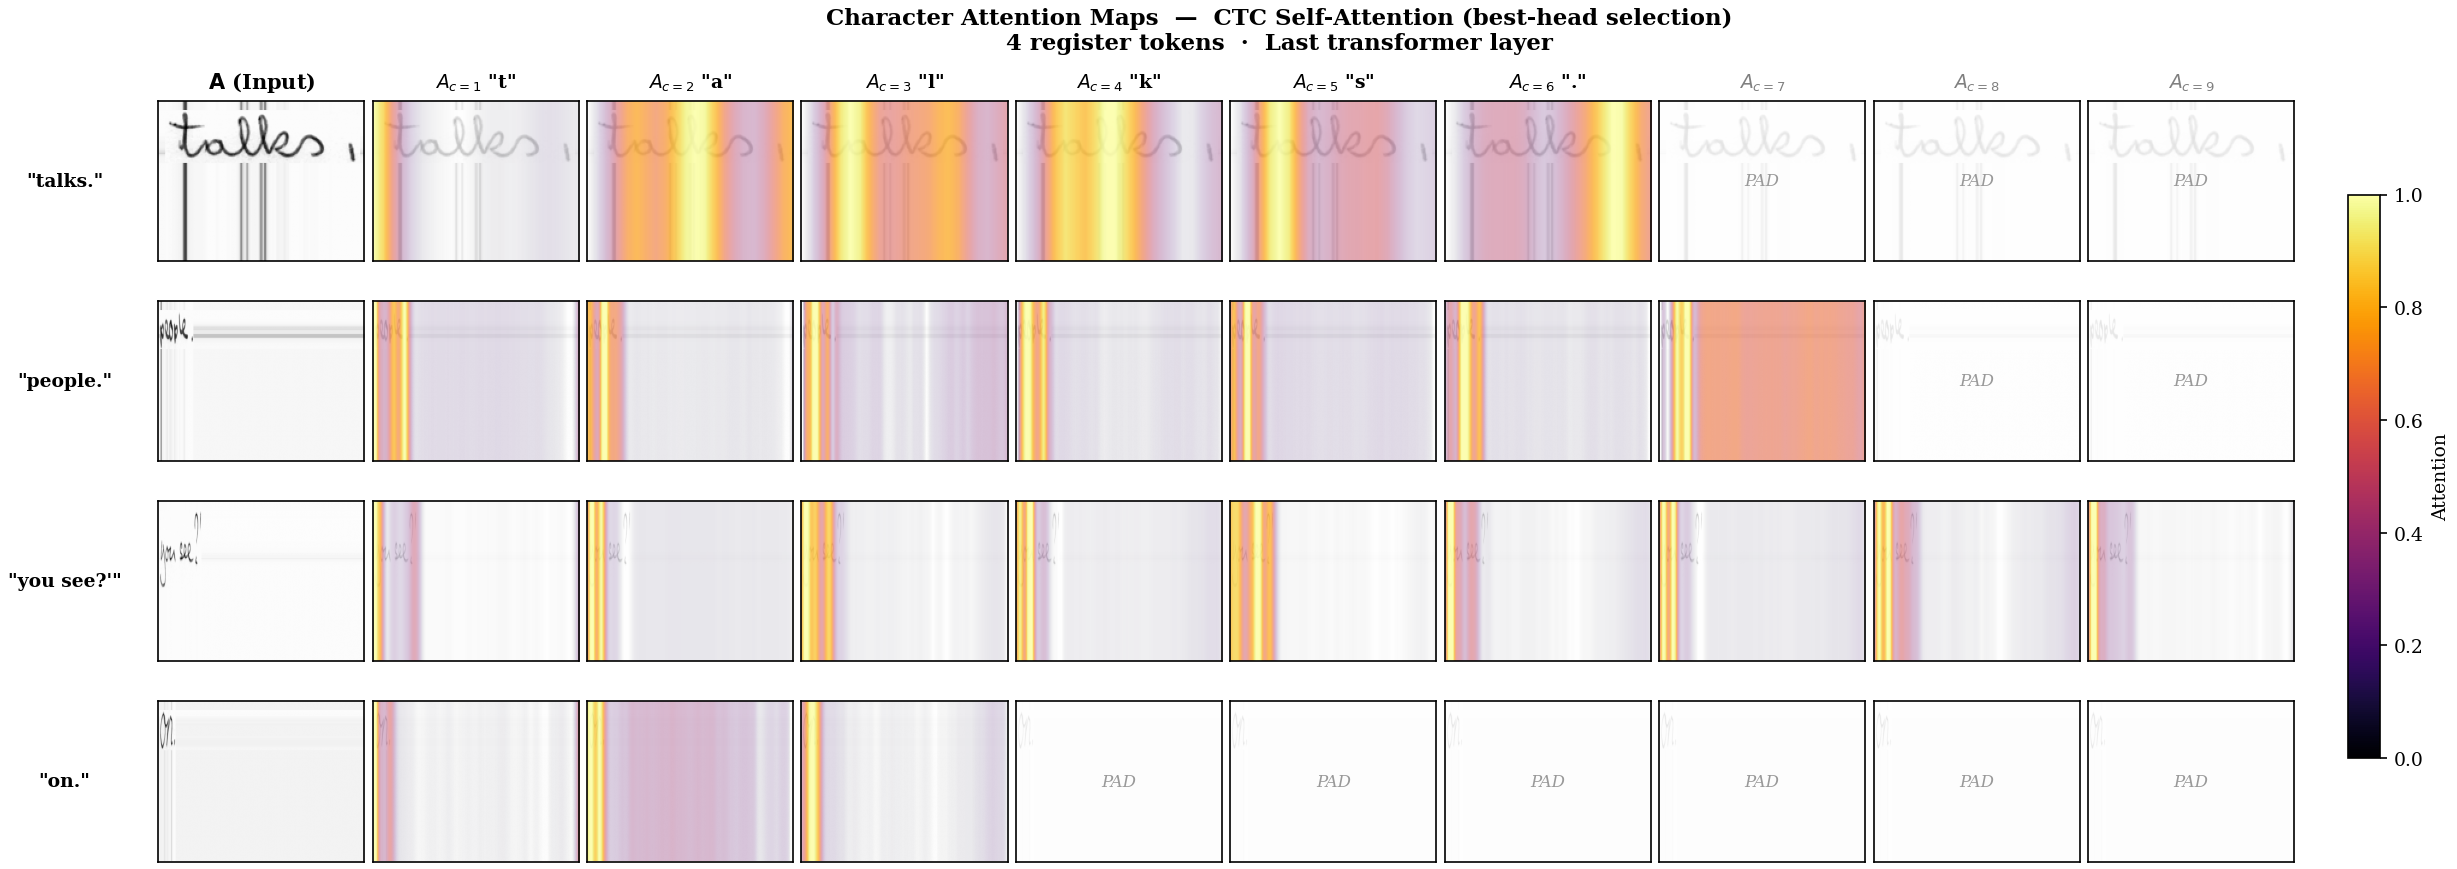

In [6]:
# ── Cell 6: Generate Fig. 5 (Self-Attention) — 4 words, 4 register tokens ──

image_list = [
    (SAMPLE_DIR / 'a01-038-12.png',  'talks.'),
    (SAMPLE_DIR / 'a01-096u-10.png', 'people.'),
    (SAMPLE_DIR / 'r06-137-10.png',  "you see?'"),
    (SAMPLE_DIR / 'a06-110-08.png',  'on.'),
]

_ = plot_fig5_self_attention(image_list, 'run_84', num_reg=4,
                              save_name='fig5_ctc_self_attention_4reg')

---
## Method 2: Gradient Saliency Character Maps

**Principle**: For each character $c$ predicted at CTC timestep $t_c$ with class $k_c$:  
$$S_c = \left| \frac{\partial \text{logit}_{t_c, k_c}}{\partial \mathbf{x}} \right|$$

This gives a true **2D pixel-level** attribution map — complementary to self-attention, which is inherently 1D in our architecture.

In [7]:
# ── Cell 7: Gradient saliency extraction ──

def compute_char_saliency(model, tensor, peak_t, class_idx):
    """
    Gradient saliency |∂logit[t,c] / ∂input| → 2D heatmap.
    
    Unlike self-attention (1D for our architecture), gradient saliency
    gives a genuine 2D spatial map at pixel resolution.
    """
    inp = tensor.clone().detach().requires_grad_(True)
    model.zero_grad()
    logits = model(inp)  # [T, B, C]
    logits[peak_t, 0, class_idx].backward()
    grad = inp.grad[0, 0].abs().cpu().numpy()  # [H, W]
    grad = gaussian_filter(grad, sigma=3)
    return grad


def extract_char_saliency_maps(model, tensor, img_proc):
    """
    Extract per-character 2D gradient saliency maps.
    
    Returns:
        decoded_text: str
        heatmaps: list of 2D numpy arrays (one per char), cropped to text region
        img_crop: cropped input image
    """
    with torch.no_grad():
        logits = model(tensor)
    text, peaks, class_ids = ctc_decode(logits)
    
    img_crop, (y0, y1, x0, x1) = tight_crop(img_proc, pad=10)
    
    heatmaps = []
    for ci, (t_c, k_c) in enumerate(zip(peaks, class_ids)):
        sal = compute_char_saliency(model, tensor, t_c, k_c)
        sal_crop = sal[y0:y1, x0:x1]
        
        # Percentile normalization
        p2, p98 = np.percentile(sal_crop, 2), np.percentile(sal_crop, 98)
        if p98 > p2:
            sal_norm = np.clip((sal_crop - p2) / (p98 - p2), 0, 1)
        else:
            sal_norm = np.zeros_like(sal_crop)
        heatmaps.append(sal_norm)
    
    return text, heatmaps, img_crop, (y0, y1, x0, x1)

print('Gradient saliency functions ready.')

Gradient saliency functions ready.


In [8]:
# ── Cell 8: Paper Fig. 5 — Gradient Saliency Grid ──

def plot_fig5_saliency(image_list, run_id, num_reg, seq_len=None, save_name=None):
    """
    Reproduce Fig. 5 from 'Beyond Memorization' using gradient saliency.
    Same layout: Rows = words, Columns = [Input | A_1 | ... | A_L].
    """
    model = load_model(run_id)
    cmap = plt.cm.inferno
    
    all_data = []
    for img_path, gt in image_list:
        tensor, img_proc = prep_image(img_path)
        text, heatmaps, img_crop, crop_box = extract_char_saliency_maps(
            model, tensor, img_proc)
        all_data.append({
            'gt': gt, 'decoded': text, 'heatmaps': heatmaps,
            'img_crop': img_crop, 'crop_box': crop_box
        })
        print(f'  "{gt}" → "{text}"  ({len(heatmaps)} chars)')
    
    del model
    
    if seq_len is None:
        seq_len = max(len(d['decoded']) for d in all_data)
    n_rows = len(all_data)
    n_cols = seq_len + 1
    
    cell_w = max(1.6, 11.0 / n_cols)
    ar = all_data[0]['img_crop'].shape[0] / all_data[0]['img_crop'].shape[1]
    cell_h = max(1.0, cell_w * ar)
    
    fig = plt.figure(figsize=(cell_w * n_cols + 1.8, cell_h * n_rows + 1.5))
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                           wspace=0.04, hspace=0.25,
                           left=0.08, right=0.88, top=0.85, bottom=0.04)
    
    for ri, d in enumerate(all_data):
        n_chars = len(d['decoded'])
        
        ax = fig.add_subplot(gs[ri, 0])
        ax.imshow(d['img_crop'], cmap='gray_r', aspect='auto')
        ax.set_ylabel(f'"{d["gt"]}"', fontsize=9, fontweight='bold',
                       rotation=0, labelpad=45, va='center')
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0:
            ax.set_title('$\\mathbf{A}$ (Input)', fontsize=10, fontweight='bold', pad=6)
        
        for ci in range(seq_len):
            ax = fig.add_subplot(gs[ri, ci + 1])
            
            if ci < n_chars and ci < len(d['heatmaps']):
                ch = d['decoded'][ci]
                hm = d['heatmaps'][ci]
                
                ax.imshow(d['img_crop'], cmap='gray_r', aspect='auto', alpha=0.25)
                rgba = cmap(hm)
                rgba[..., 3] = hm * 0.85
                ax.imshow(rgba, aspect='auto')
                
                if ri == 0:
                    label = ch if ch != ' ' else '⎵'
                    ax.set_title(f'$A_{{c={ci+1}}}$ "{label}"', fontsize=9,
                                 fontweight='bold', pad=6)
            else:
                ax.imshow(d['img_crop'], cmap='gray_r', aspect='auto', alpha=0.12)
                ax.text(0.5, 0.5, 'PAD', transform=ax.transAxes,
                        ha='center', va='center', fontsize=8,
                        color='#999999', fontstyle='italic')
                if ri == 0:
                    ax.set_title(f'$A_{{c={ci+1}}}$', fontsize=9, color='gray', pad=6)
            
            ax.set_xticks([]); ax.set_yticks([])
    
    fig.suptitle(
        f'Character Attention Maps  —  Gradient Saliency $|\\partial \\mathrm{{logit}}/\\partial \\mathbf{{x}}|$\n'
        f'{num_reg} register tokens',
        fontsize=11, fontweight='bold', y=0.95)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=Normalize(0, 1))
    sm.set_array([])
    cax = fig.add_axes([0.90, 0.15, 0.012, 0.60])
    fig.colorbar(sm, cax=cax, label='Saliency')
    
    if save_name:
        for ext in ['.png', '.pdf']:
            fig.savefig(str(OUT_DIR / (save_name + ext)), facecolor='white')
        print(f'  Saved: {save_name}.png/.pdf')
    
    plt.show(); plt.close(fig)
    return all_data

print('Saliency grid function ready.')

Saliency grid function ready.


  "talks." → "talks."  (6 chars)
  "people." → "people."  (7 chars)
  "you see?'" → "you see?'"  (9 chars)
  "on." → "on."  (3 chars)
  Saved: fig5_gradient_saliency_4reg.png/.pdf


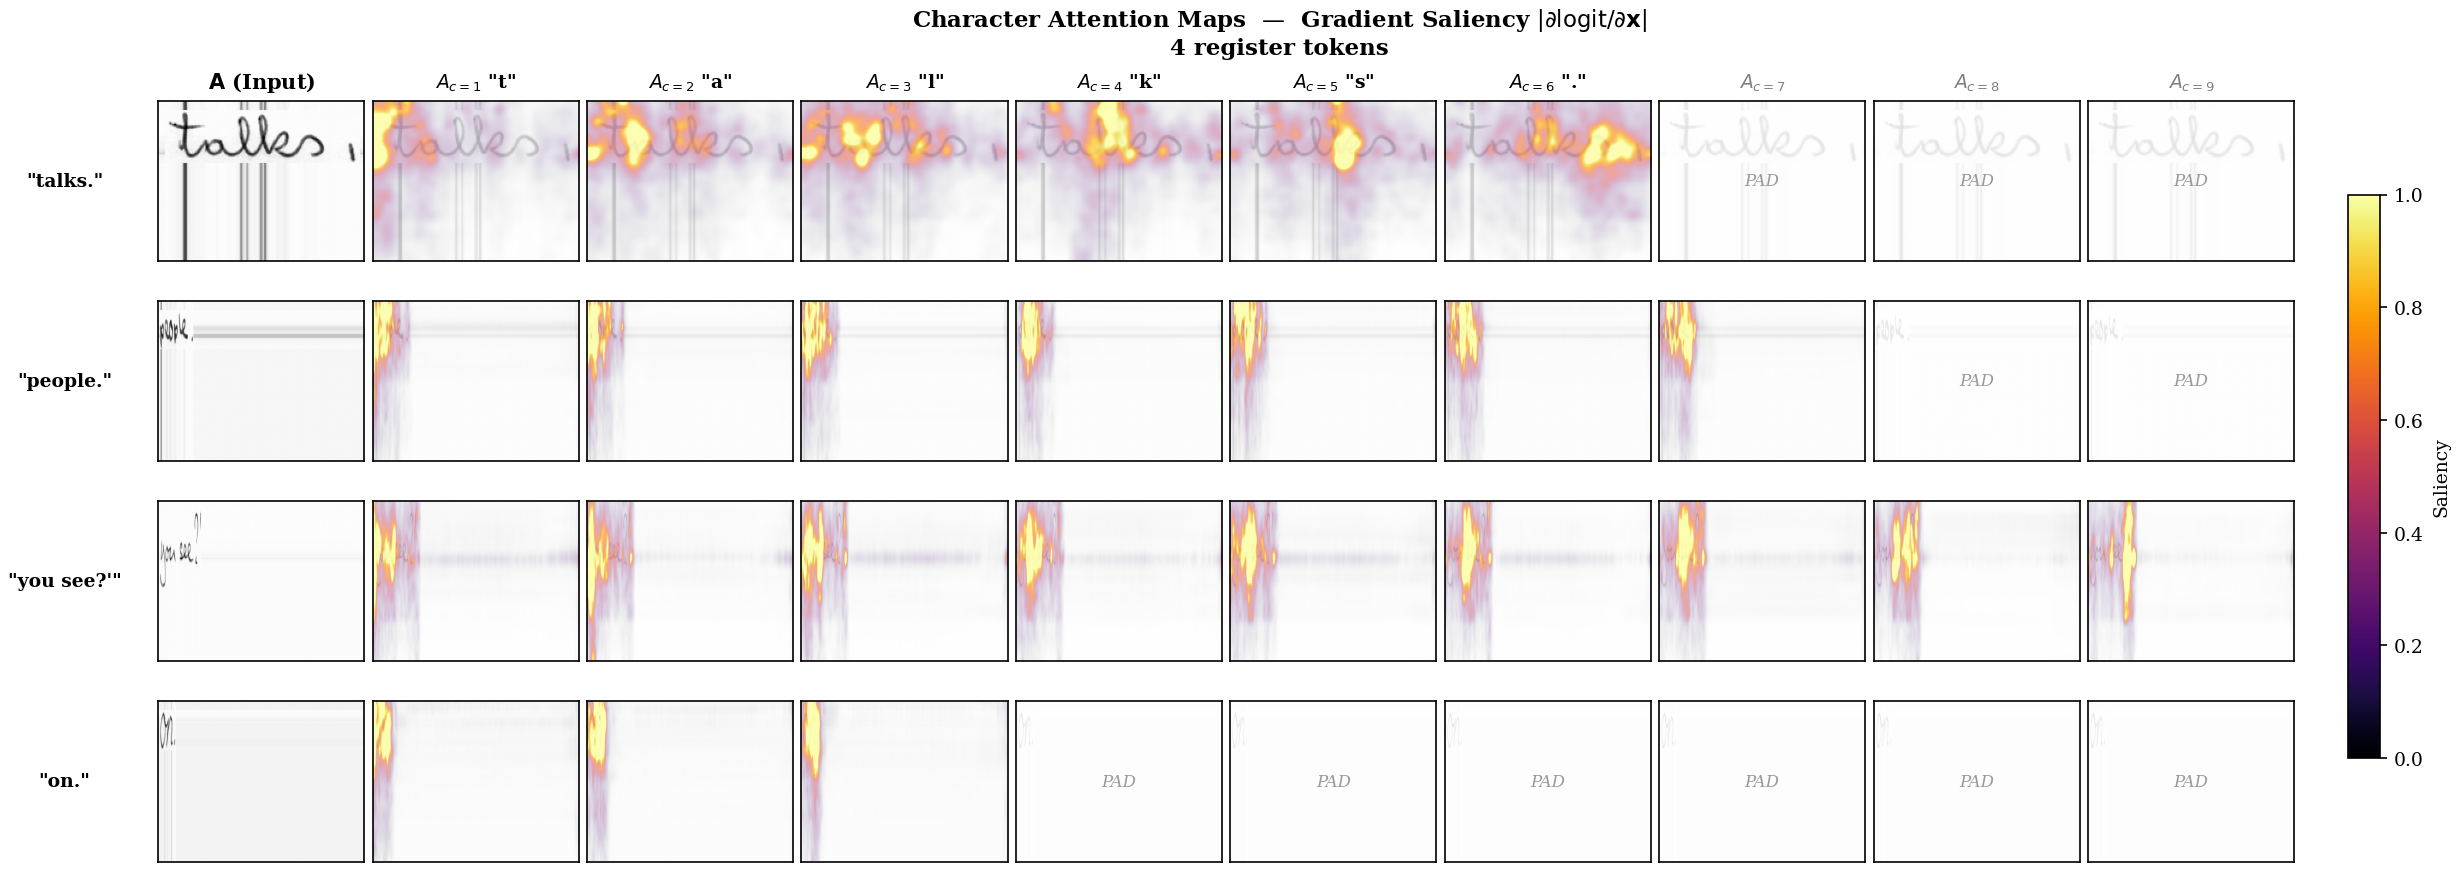

In [9]:
# ── Cell 9: Generate Fig. 5 (Saliency) — 4 words, 4 register tokens ──

image_list = [
    (SAMPLE_DIR / 'a01-038-12.png',  'talks.'),
    (SAMPLE_DIR / 'a01-096u-10.png', 'people.'),
    (SAMPLE_DIR / 'r06-137-10.png',  "you see?'"),
    (SAMPLE_DIR / 'a06-110-08.png',  'on.'),
]

_ = plot_fig5_saliency(image_list, 'run_84', num_reg=4,
                        save_name='fig5_gradient_saliency_4reg')

---
## Register Comparison: Effect on Character Attention

Shows how attention maps change with 0 / 4 / 8 / 16 register tokens for a single word.  
Layout: **Rows = register configs**, Columns = [Input | $A_1$ | $A_2$ | ... | $A_L$].

In [10]:
# ── Cell 10: Register comparison grid ──

def plot_register_comparison(img_path, gt_text, register_configs, method='attention',
                              save_name=None):
    """
    Compare character attention maps across register configurations.
    
    Args:
        method: 'attention' (self-attention) or 'saliency' (gradient)
    """
    cmap = plt.cm.inferno
    tensor, img_proc = prep_image(img_path)
    
    all_data = []
    for nr, rid in sorted(register_configs.items()):
        model = load_model(rid)
        
        if method == 'attention':
            text, heatmaps, img_crop, crop_box, bh, brho = \
                extract_char_attention_maps(model, tensor, img_proc)
            info = f'head={bh}, ρ={brho:.2f}'
        else:
            text, heatmaps, img_crop, crop_box = \
                extract_char_saliency_maps(model, tensor, img_proc)
            info = f'{len(heatmaps)} chars'
        
        all_data.append({
            'nr': nr, 'decoded': text, 'heatmaps': heatmaps,
            'img_crop': img_crop
        })
        print(f'  {nr:>2} reg: "{text}"  ({info})')
        del model
    
    seq_len = max(len(d['decoded']) for d in all_data)
    n_rows = len(all_data)
    n_cols = seq_len + 1
    
    cell_w = max(1.6, 11.0 / n_cols)
    ar = all_data[0]['img_crop'].shape[0] / all_data[0]['img_crop'].shape[1]
    cell_h = max(1.0, cell_w * ar)
    
    fig = plt.figure(figsize=(cell_w * n_cols + 1.8, cell_h * n_rows + 1.5))
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                           wspace=0.04, hspace=0.25,
                           left=0.08, right=0.88, top=0.85, bottom=0.04)
    
    # Use longest decoded text for column headers
    ref_text = max((d['decoded'] for d in all_data), key=len)
    
    for ri, d in enumerate(all_data):
        n_chars = len(d['decoded'])
        
        ax = fig.add_subplot(gs[ri, 0])
        ax.imshow(d['img_crop'], cmap='gray_r', aspect='auto')
        ax.set_ylabel(f'{d["nr"]} reg', fontsize=10, fontweight='bold',
                       labelpad=12)
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0:
            ax.set_title('Input', fontsize=10, fontweight='bold', pad=6)
        
        for ci in range(seq_len):
            ax = fig.add_subplot(gs[ri, ci + 1])
            
            if ci < n_chars and ci < len(d['heatmaps']):
                hm = d['heatmaps'][ci]
                ax.imshow(d['img_crop'], cmap='gray_r', aspect='auto', alpha=0.25)
                rgba = cmap(hm)
                rgba[..., 3] = hm * 0.85
                ax.imshow(rgba, aspect='auto')
                
                if ri == 0:
                    ch = ref_text[ci] if ci < len(ref_text) else '?'
                    label = ch if ch != ' ' else '⎵'
                    ax.set_title(f'$A_{{c={ci+1}}}$ "{label}"', fontsize=9,
                                 fontweight='bold', pad=6)
            else:
                ax.imshow(d['img_crop'], cmap='gray_r', aspect='auto', alpha=0.12)
                if ri == 0 and ci < len(ref_text):
                    ax.set_title(f'$A_{{c={ci+1}}}$', fontsize=9, color='gray', pad=6)
            
            ax.set_xticks([]); ax.set_yticks([])
    
    method_label = 'CTC Self-Attention' if method == 'attention' else 'Gradient Saliency'
    fig.suptitle(
        f'Register Effect on Character Attention  —  "{gt_text}"\n'
        f'{method_label}  ·  Rows = register configurations',
        fontsize=11, fontweight='bold', y=0.95)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=Normalize(0, 1))
    sm.set_array([])
    cax = fig.add_axes([0.90, 0.15, 0.012, 0.60])
    fig.colorbar(sm, cax=cax, label='Attention')
    
    if save_name:
        for ext in ['.png', '.pdf']:
            fig.savefig(str(OUT_DIR / (save_name + ext)), facecolor='white')
        print(f'  Saved: {save_name}.png/.pdf')
    
    plt.show(); plt.close(fig)

print('Register comparison function ready.')

Register comparison function ready.


   0 reg: "talks."  (head=0, ρ=0.03)
   4 reg: "talks."  (head=5, ρ=0.43)
   8 reg: "talks."  (head=7, ρ=0.09)
  16 reg: "talks."  (head=4, ρ=-0.03)
  Saved: fig5_register_comparison_attn_talks.png/.pdf


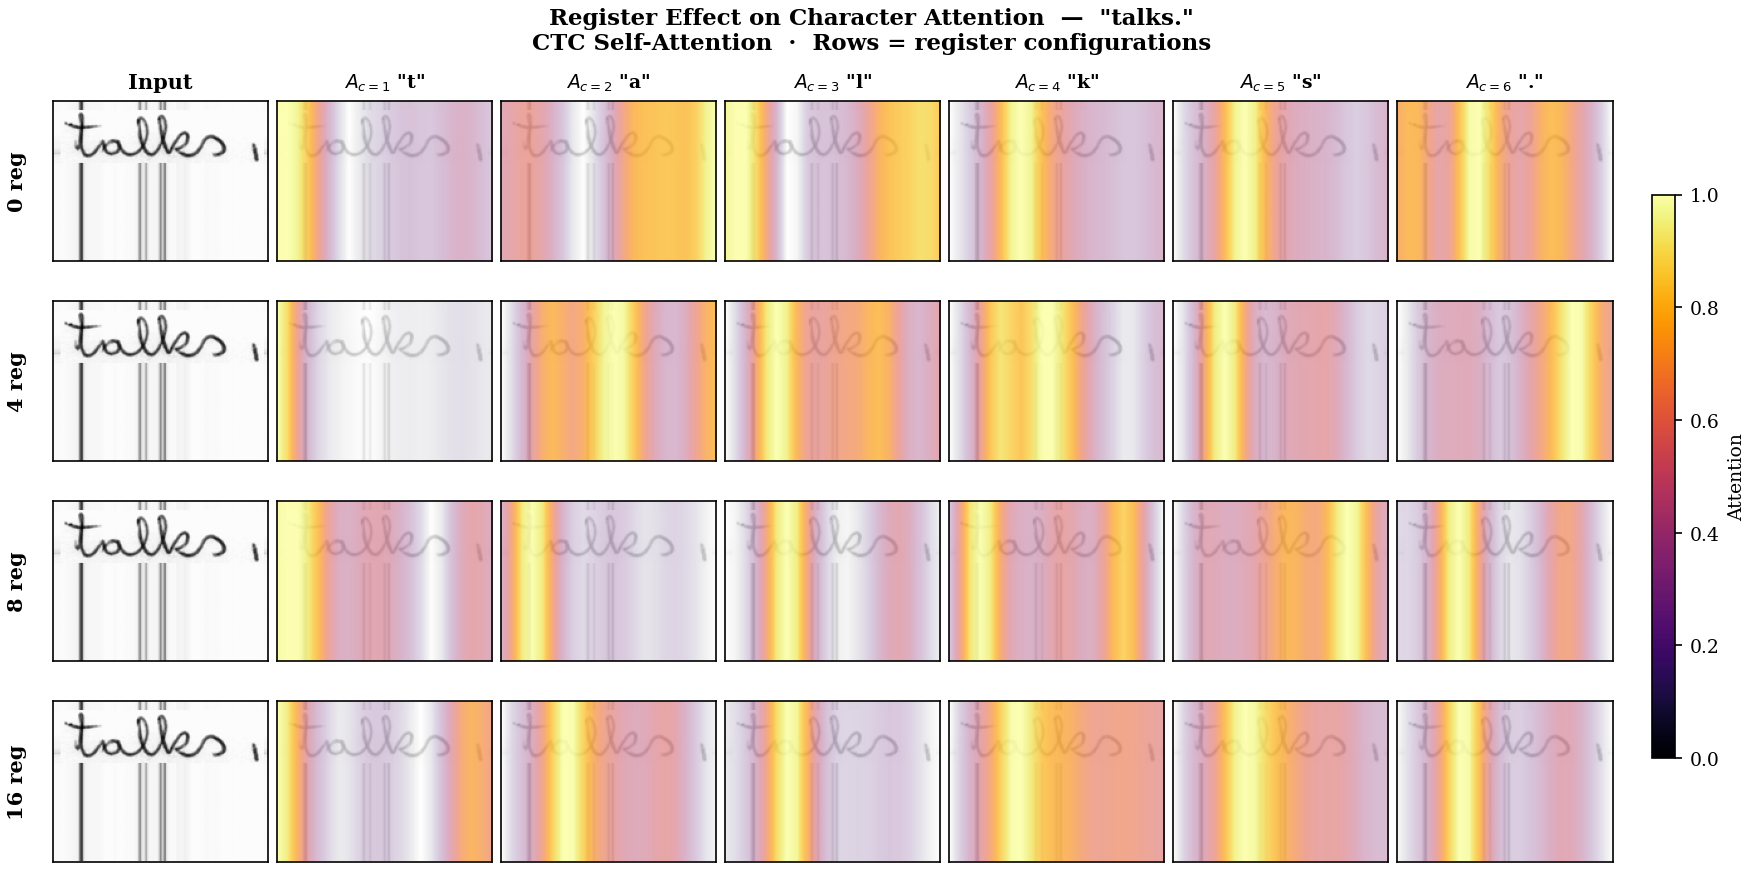

In [11]:
# ── Cell 11: Register comparison — "talks." (Self-Attention) ──
plot_register_comparison(
    SAMPLE_DIR / 'a01-038-12.png', 'talks.', RUNS,
    method='attention',
    save_name='fig5_register_comparison_attn_talks')

In [12]:
# ── Cell 12: Register comparison — "talks." (Gradient Saliency) ──
plot_register_comparison(
    SAMPLE_DIR / 'a01-038-12.png', 'talks.', RUNS,
    method='saliency',
    save_name='fig5_register_comparison_sal_talks')

   0 reg: "talks."  (6 chars)
   4 reg: "talks."  (6 chars)
   8 reg: "talks."  (6 chars)


: 

In [ ]:
# ── Cell 13: Register comparison — "supporters." (Self-Attention) ──
plot_register_comparison(
    SAMPLE_DIR / 'a01-091-10.png', 'supporters.', RUNS,
    method='attention',
    save_name='fig5_register_comparison_attn_supporters')

---
## Summary

### Generated Figures

| Figure | Method | Layout | File |
|--------|--------|--------|------|
| Fig. 5a | CTC Self-Attention (best head) | Rows=words, Cols=chars | `fig5_ctc_self_attention_4reg` |
| Fig. 5b | Gradient Saliency ($|\partial/\partial x|$) | Rows=words, Cols=chars | `fig5_gradient_saliency_4reg` |
| Fig. 5c | Self-Attention register sweep | Rows=0/4/8/16 reg, Cols=chars | `fig5_register_comparison_attn_talks` |
| Fig. 5d | Saliency register sweep | Rows=0/4/8/16 reg, Cols=chars | `fig5_register_comparison_sal_talks` |
| Fig. 5e | Self-Attention register sweep | Rows=0/4/8/16 reg, Cols=chars | `fig5_register_comparison_attn_supporters` |

### Scientific Notes

1. **Self-attention** produces 1D maps (width only) because the CNN stem collapses height before the transformer. Maps are tiled vertically for visualization.
2. **Gradient saliency** gives true 2D pixel-level maps but requires backpropagation — slower but more spatially informative.
3. **Best-head selection** (Spearman $\rho$ of character order vs. attention centroid) is critical — head-averaging produces near-uniform maps.
4. **Register tokens** are expected to absorb global/background information, leaving character-aligned heads with cleaner spatial focus.